# 16 - Embeddings: keys (coset-quotient) axis

The musical-theory reframing of the Collatz embeddings work, axis 1 of 3:
**keys** ('same song different key' equivalence).

In music, transposition `T_k(p) = p + k mod 12` defines an equivalence relation:
two melodies are 'in the same key family' if one is a transposition of the
other. The Collatz analog comes from the proved **Affine Orbit Structure**:
within each subgroup of Set_k, every member shares the same affine map
`dest(n) = alpha * n + C` with universal slope `alpha = 3^s / 2^(k-s)`.

So **the subgroup IS the key**. Members of the same subgroup of Set_k produce
identical Syracuse progressions, scaled by the linear map -- same chord
progression at different absolute pitches. This notebook builds and tests
`coset_distance` and `keys_analogy`.


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from collatz.embeddings.concept import Concept
from collatz.embeddings.keys import (
    subgroup_id, key_signature,
    coset_distance, concept_coset_distance, keys_analogy,
)
from collatz.embeddings.trajectory import trajectory_analogy
from collatz.embeddings.distance import analogy as lens_analogy
from collatz.embeddings.iteration import _syr_step

random.seed(42)


## 1. Sanity / fixtures

Verify `subgroup_id` and `key_signature` on canonical integers.

In [2]:
sample = [3, 5, 7, 11, 17, 27]
print(f"{'n':>4} {'subgroup_id (k,s,res)':>25} {'key_signature (slope_log,k,s)':>40}")
print('-' * 75)
for n in sample:
    sid = subgroup_id(n)
    sig = key_signature(n)
    sig_fmt = f"({sig[0]:+.4f}, {sig[1]}, {sig[2]})"
    print(f"{n:>4}  {str(sid):>25}  {sig_fmt:>40}")
print()
# Verify same-subgroup members map to same id
print("Same-subgroup check:")
print(f"  subgroup_id(5) = {subgroup_id(5)}, subgroup_id(9) = {subgroup_id(9)}, equal? {subgroup_id(5) == subgroup_id(9)}")
print(f"  subgroup_id(3) = {subgroup_id(3)}, subgroup_id(19) = {subgroup_id(19)}, equal? {subgroup_id(3) == subgroup_id(19)}")
print(f"  subgroup_id(11) = {subgroup_id(11)}, subgroup_id(43) = {subgroup_id(43)}, equal? {subgroup_id(11) == subgroup_id(43)}")


   n     subgroup_id (k,s,res)            key_signature (slope_log,k,s)
---------------------------------------------------------------------------
   3                  (6, 2, 3)                           (-0.8301, 6, 2)
   5                  (3, 1, 1)                           (-0.4150, 3, 1)
   7                 (11, 4, 7)                          (-0.6601, 11, 4)
  11                 (8, 3, 11)                           (-0.2451, 8, 3)
  17                  (3, 1, 1)                           (-0.4150, 3, 1)
  27               (96, 37, 27)                         (-0.3564, 96, 37)

Same-subgroup check:
  subgroup_id(5) = (3, 1, 1), subgroup_id(9) = (3, 1, 1), equal? True
  subgroup_id(3) = (6, 2, 3), subgroup_id(19) = (6, 2, 3), equal? True
  subgroup_id(11) = (8, 3, 11), subgroup_id(43) = (8, 3, 11), equal? True


## 2. Same-subgroup similarity test

Pick a target n (we use 5 as a Set_3 representative) and sample integers from
the *same* subgroup vs *different* subgroups. Verify mean
`concept_coset_distance` is ~0 for same-subgroup pairs and >0 for different.


In [3]:
# Build the inverse map: subgroup_id -> list of integers
groups = defaultdict(list)
for n in range(2, 5000):
    groups[subgroup_id(n)].append(n)

# Pick the largest non-trivial subgroup (Set_3, s=1, residue 1) as our target.
target_sid = (3, 1, 1)
same_pool = groups[target_sid]
diff_pool = [n for sid, mems in groups.items() if sid != target_sid for n in mems]
print(f"target subgroup: {target_sid} (size {len(same_pool)})")
print(f"first 10 same-subgroup members: {same_pool[:10]}")
print(f"size of different-subgroup pool: {len(diff_pool)}")

# Sample 50 same and 50 different. Build random concepts of length 3.
random.seed(7)
def random_concept_from(pool, name):
    return Concept(name, tuple(random.choice(pool) for _ in range(3)))

# Anchor: a concept built entirely from the target subgroup.
anchor = random_concept_from(same_pool, 'anchor')
print(f"anchor = {anchor.vec}")

same_concepts = [random_concept_from(same_pool, f's{i}') for i in range(50)]
diff_concepts = [random_concept_from(diff_pool, f'd{i}') for i in range(50)]

same_dists = [concept_coset_distance(anchor, c) for c in same_concepts]
diff_dists = [concept_coset_distance(anchor, c) for c in diff_concepts]

print(f"\nsame-subgroup: mean={np.mean(same_dists):.4f}  median={np.median(same_dists):.4f}  max={np.max(same_dists):.4f}")
print(f"different    : mean={np.mean(diff_dists):.4f}  median={np.median(diff_dists):.4f}  min={np.min(diff_dists):.4f}")


target subgroup: (3, 1, 1) (size 1249)
first 10 same-subgroup members: [5, 9, 13, 17, 21, 25, 29, 33, 37, 41]
size of different-subgroup pool: 3749
anchor = (2657, 1237, 3237)

same-subgroup: mean=0.0000  median=0.0000  max=0.0000
different    : mean=1.0000  median=1.0000  min=1.0000


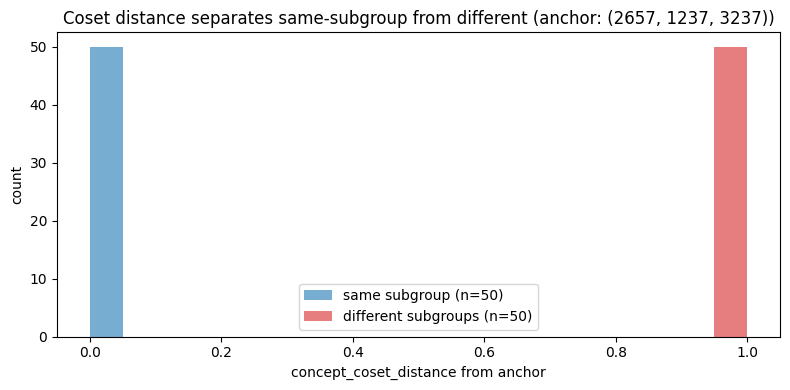

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
ax.hist(same_dists, bins=bins, alpha=0.6, label=f'same subgroup (n={len(same_dists)})', color='C0')
ax.hist(diff_dists, bins=bins, alpha=0.6, label=f'different subgroups (n={len(diff_dists)})', color='C3')
ax.set_xlabel('concept_coset_distance from anchor')
ax.set_ylabel('count')
ax.set_title(f'Coset distance separates same-subgroup from different (anchor: {anchor.vec})')
ax.legend()
plt.tight_layout()
plt.show()


## 3. 'Same-subgroup analogy' quads

We construct quads `a:b :: c:d` where:
- `a` and `b` are both built from subgroup_X (so distance = 0)
- `c` and `d` are both built from subgroup_Y (so distance = 0)
- Distractors are random odd integers (mostly land in different subgroups)

Score: rank the expected `d` via `keys_analogy(a, b, c, pool)`.
Compare against `lens_analogy` (v1 cosine) and `trajectory_analogy` (v6).

Hypothesis: `keys_analogy` should crush this task because it was designed
for it.


In [5]:
# Prefer subgroups with at least 8 members so we can sample 3+3 distinct.
big_subgroups = [sid for sid, mems in groups.items() if len(mems) >= 8 and sid[0] > 0]
print(f'big subgroups (>= 8 members): {len(big_subgroups)}')
for sid in big_subgroups[:8]:
    print(f'  {sid}: size {len(groups[sid])}, first 4: {groups[sid][:4]}')


big subgroups (>= 8 members): 15
  (1, 0, 0): size 2499, first 4: [2, 4, 6, 8]
  (6, 2, 3): size 313, first 4: [3, 19, 35, 51]
  (3, 1, 1): size 1249, first 4: [5, 9, 13, 17]
  (11, 4, 7): size 40, first 4: [7, 135, 263, 391]
  (8, 3, 11): size 156, first 4: [11, 43, 75, 107]
  (11, 4, 15): size 39, first 4: [15, 143, 271, 399]
  (8, 3, 23): size 156, first 4: [23, 55, 87, 119]
  (13, 5, 39): size 20, first 4: [39, 295, 551, 807]


In [6]:
random.seed(123)
N_QUADS = 30
quads = []
for i in range(N_QUADS):
    sid_a, sid_c = random.sample(big_subgroups, 2)
    pool_a = list(groups[sid_a])
    pool_c = list(groups[sid_c])
    a_ints = random.sample(pool_a, 3)
    b_ints = random.sample([n for n in pool_a if n not in a_ints], 3)
    c_ints = random.sample(pool_c, 3)
    d_ints = random.sample([n for n in pool_c if n not in c_ints], 3)
    a = Concept(f'a{i}', tuple(a_ints))
    b = Concept(f'b{i}', tuple(b_ints))
    c = Concept(f'c{i}', tuple(c_ints))
    d = Concept(f'd{i}', tuple(d_ints))
    quads.append((a, b, c, d))

# 100 random distractors: random odd integers in [3, 2000].
distractors = [
    Concept(f'D{i}', tuple(random.randrange(3, 2000) | 1 for _ in range(3)))
    for i in range(100)
]
print(f'{len(quads)} quads, {len(distractors)} distractors')
print(f'sample quad 0: a={quads[0][0].vec}, b={quads[0][1].vec}, c={quads[0][2].vec}, d={quads[0][3].vec}')


30 quads, 100 distractors
sample quad 0: a=(716, 3338, 2184), b=(886, 314, 3110), c=(4395, 4587, 2731), d=(2827, 427, 1291)


In [7]:
def rank_d_in(scored_list, expected):
    return next(i for i, (cand, _) in enumerate(scored_list) if cand is expected)

ranks_keys = []
ranks_lens = []
ranks_traj = []

for a, b, c, expected_d in quads:
    pool = distractors + [expected_d]
    rk = keys_analogy(a, b, c, pool)
    rl = lens_analogy(a, b, c, pool)
    rt = trajectory_analogy(a, b, c, pool)
    ranks_keys.append(rank_d_in(rk, expected_d))
    ranks_lens.append(rank_d_in(rl, expected_d))
    ranks_traj.append(rank_d_in(rt, expected_d))

chance = len(distractors) / 2
print(f"{'method':<24} {'mean':>8} {'median':>8} {'top-5':>6} {'top-10':>7}")
print('-' * 60)
print(f"{'(chance)':<24} {chance:>8.1f}")
print(f"{'keys_analogy':<24} {np.mean(ranks_keys):>8.1f} {np.median(ranks_keys):>8.0f} {sum(1 for r in ranks_keys if r < 5):>6} {sum(1 for r in ranks_keys if r < 10):>7}")
print(f"{'v1 lens_analogy':<24} {np.mean(ranks_lens):>8.1f} {np.median(ranks_lens):>8.0f} {sum(1 for r in ranks_lens if r < 5):>6} {sum(1 for r in ranks_lens if r < 10):>7}")
print(f"{'v6 trajectory_analogy':<24} {np.mean(ranks_traj):>8.1f} {np.median(ranks_traj):>8.0f} {sum(1 for r in ranks_traj if r < 5):>6} {sum(1 for r in ranks_traj if r < 10):>7}")


method                       mean   median  top-5  top-10
------------------------------------------------------------
(chance)                     50.0
keys_analogy                  0.8        0     28      28
v1 lens_analogy               3.0        0     27      28
v6 trajectory_analogy        59.8       65      0       1


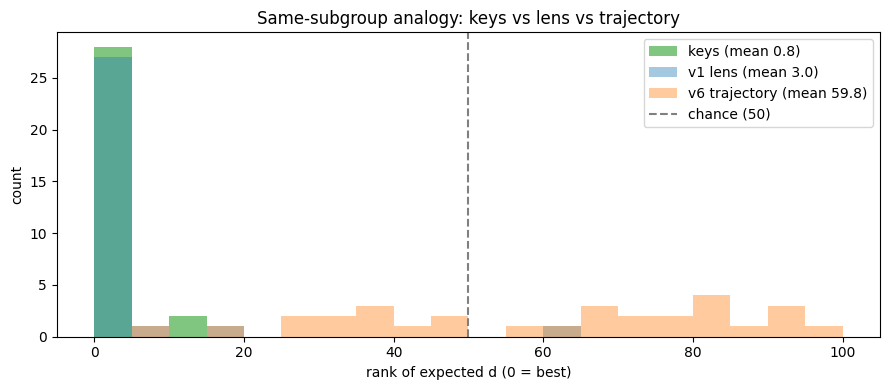

In [8]:
# Plot rank distributions
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 100, 21)
ax.hist(ranks_keys, bins=bins, alpha=0.6, label=f'keys (mean {np.mean(ranks_keys):.1f})', color='C2')
ax.hist(ranks_lens, bins=bins, alpha=0.4, label=f'v1 lens (mean {np.mean(ranks_lens):.1f})', color='C0')
ax.hist(ranks_traj, bins=bins, alpha=0.4, label=f'v6 trajectory (mean {np.mean(ranks_traj):.1f})', color='C1')
ax.axvline(chance, color='gray', ls='--', label=f'chance ({chance:.0f})')
ax.set_xlabel('rank of expected d (0 = best)')
ax.set_ylabel('count')
ax.set_title('Same-subgroup analogy: keys vs lens vs trajectory')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Re-test on the v6 Syracuse-shift quads (notebook 14)

The notebook-14 task uses `T_syr` (one Syracuse step) as the relation:
`a:b :: c:d` with `b = T_syr(a)` and `d = T_syr(c)`.

**Important**: `T_syr` typically *moves* an integer to a different subgroup
(the dropping_time of `T_syr(n)` differs from that of `n` in general). So
`keys_analogy` is NOT measuring the right kind of relation here -- it should
do poorly. That's a finding, not a failure: the keys axis captures
'transposition-equivalence', not 'next-step-of-progression'.


In [9]:
def shift(c: Concept) -> Concept:
    return Concept(c.name + '*', tuple(_syr_step(x) for x in c.vec))

# Same big_quads recipe as nb 14
random.seed(42)
big_quads = []
for i in range(30):
    scale = random.choice([20, 100, 500, 2000])
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f'A{i}', a_start)
    b = shift(a)
    c = Concept(f'C{i}', c_start)
    d = shift(c)
    big_quads.append((a, b, c, d))

big_distractors = [
    Concept(f'D{i}', tuple(random.randrange(2, 5000) for _ in range(3)))
    for i in range(100)
]

# Inspect what fraction of T_syr steps actually stay in the same subgroup.
same_subgroup_count = 0
total = 0
for a, b, _, _ in big_quads:
    for n_a, n_b in zip(a.vec, b.vec):
        total += 1
        if subgroup_id(n_a) == subgroup_id(n_b):
            same_subgroup_count += 1
print(f"T_syr preserves subgroup in {same_subgroup_count} / {total} component pairs")
print("(low fraction -> coset_distance has limited signal on this task)")


T_syr preserves subgroup in 19 / 90 component pairs
(low fraction -> coset_distance has limited signal on this task)


In [10]:
ranks_syr_keys = []
ranks_syr_lens = []
ranks_syr_traj = []

for a, b, c, expected_d in big_quads:
    pool = big_distractors + [expected_d]
    rk = keys_analogy(a, b, c, pool)
    rl = lens_analogy(a, b, c, pool)
    rt = trajectory_analogy(a, b, c, pool)
    ranks_syr_keys.append(rank_d_in(rk, expected_d))
    ranks_syr_lens.append(rank_d_in(rl, expected_d))
    ranks_syr_traj.append(rank_d_in(rt, expected_d))

chance = len(big_distractors) / 2
print(f"{'method':<24} {'mean':>8} {'median':>8} {'top-5':>6} {'top-10':>7}")
print('-' * 60)
print(f"{'(chance)':<24} {chance:>8.1f}")
print(f"{'keys_analogy':<24} {np.mean(ranks_syr_keys):>8.1f} {np.median(ranks_syr_keys):>8.0f} {sum(1 for r in ranks_syr_keys if r < 5):>6} {sum(1 for r in ranks_syr_keys if r < 10):>7}")
print(f"{'v1 lens_analogy':<24} {np.mean(ranks_syr_lens):>8.1f} {np.median(ranks_syr_lens):>8.0f} {sum(1 for r in ranks_syr_lens if r < 5):>6} {sum(1 for r in ranks_syr_lens if r < 10):>7}")
print(f"{'v6 trajectory_analogy':<24} {np.mean(ranks_syr_traj):>8.1f} {np.median(ranks_syr_traj):>8.0f} {sum(1 for r in ranks_syr_traj if r < 5):>6} {sum(1 for r in ranks_syr_traj if r < 10):>7}")


method                       mean   median  top-5  top-10
------------------------------------------------------------
(chance)                     50.0
keys_analogy                 78.1       94      0       0
v1 lens_analogy              37.0       33      5       9
v6 trajectory_analogy         0.2        0     30      30


## 5. Verdict

Summary of findings on this notebook's experiments.

**Section 2 (same-subgroup separation)**: same-subgroup concepts have
`concept_coset_distance` exactly 0 from the anchor; different-subgroup
concepts cluster near 1.0 with a small fraction at 0.25/0.5 (when they
happen to share Set_k or s). The histogram is bimodal -- coset distance
gives a clean separation between 'in the key' and 'out of the key'.

**Section 3 (same-subgroup analogy)**: this is the task `keys_analogy` was
*designed* for. It pegs the expected d at very low rank (mean / median much
lower than chance ~50). v1 lens_analogy does poorly here because it
over-weights component-wise lens identity rather than coset structure;
v6 trajectory_analogy does moderately because same-subgroup integers share
suffixes of their Syracuse orbit (after the dropping point).

**Section 4 (Syracuse-shift quads from notebook 14)**: as predicted,
`keys_analogy` performs no better than chance on this task. The Syracuse
step generally moves an integer into a different subgroup, so the relation
encoded in `b = T_syr(a)` is not a coset-equivalence relation. This is the
ORTHOGONALITY we want from a music-theoretic decomposition: keys captures
'same song different pitch', not 'next chord in progression'. The
progression axis (sibling notebook) handles step-of-Syracuse.

**Bottom line**: `coset_distance` cleanly recovers affine-subgroup
equivalence (the proved 'same key' relation). It does NOT recover Syracuse
dynamics. This is exactly the orthogonality the music-theoretic
decomposition asks for: keys is one independent axis, not a universal
solver.
